In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sc

In [2]:
# load TE
TE = pd.read_csv("rm_out_dir/Csec.fa.modified_col.out", comment='#', sep=' ', header=None, skipinitialspace=True)
TE_header = 'SW_score perc_div perc_del perc_ins query_seq query_seq_begin query_seq_end query_seq_left comp/cons matching_repeat repeat_class_family repeat_seq_begin repeat_seq_end repeat_seq_left ID higher_score'.split(' ')
TE.columns = TE_header
TE['class'] = [ i.split('/')[0] for i in TE["repeat_class_family"]]
TE['family'] = [ i.split('/')[-1] for i in TE["repeat_class_family"]]
TE['scaffold']=TE['query_seq']

In [3]:
def get_frac_per_win(TE, TE_type="all", winsize=10_000):
    if not TE_type=="all":
        TE=TE.loc[TE["class"]==TE_type]
    win_dict = {}
    win_size = winsize
    for i, te in TE.iterrows():
        
        # check bin TE is starting in:
        bin_id = np.floor((te.query_seq_begin/win_size))
        bin_bottom= bin_id*win_size
        bin_top = (bin_id+1)*win_size
        win_dict.setdefault(te.scaffold, {}).setdefault(bin_id, {"counter":0,'id':[], "type":[],"frac":0, "lens":[] })
        win_dict[te.scaffold][bin_id]["counter"] +=1
        win_dict[te.scaffold][bin_id]["id"].append(te.matching_repeat)
        win_dict[te.scaffold][bin_id]["type"].append(te['class'])
        frac = (np.min([bin_top,te.query_seq_end]) - np.max([bin_bottom, te.query_seq_begin]))
        win_dict[te.scaffold][bin_id]["lens"].append(frac)
        win_dict[te.scaffold][bin_id]["frac"] += frac
        while te.query_seq_end>(bin_top*win_size):
            bin_id = bin_id+1
            bin_bottom= bin_id*win_size
            bin_top = (bin_id+1)*win_size
            win_dict.setdefault(bin_id, {"counter":0,'id':[], "type":[],frac:0 })
            win_dict[te.scaffold][bin_id]["counter"] +=1
            win_dict[te.scaffold][bin_id]["id"].append(te.matching_repeat)
            win_dict[te.scaffold][bin_id]["type"].append(te['class'])
            frac = (np.min([bin_top,te.query_seq_end]) - np.max([bin_bottom, te.query_seq_begin]))
            win_dict[te.scaffold][bin_id]["lens"].append(frac)
            win_dict[te.scaffold][bin_id]["frac"] += frac
            
 
    frac_df_all = []
    for scaffold, item in win_dict.items():
        for bin_name, values in item.items():
            line = [scaffold, bin_name*win_size, (bin_name+1)*win_size, values['frac']]
            frac_df_all.append(line)
    frac_df_all = pd.DataFrame(frac_df_all)
    frac_df_all.columns = ["scaffold", 'start_bin', "stop_win", "frac_rep"]
    
    return win_dict, frac_df_all

In [4]:
def get_peaks(data,bin_size_kb=2, comp_flanksize_kb=50, fold_thresh=5):
    scaff_l = list(set(data.Scaffold))
    peak = []
    nopeak = []
    
    for scaff in scaff_l:
        onekbfile = data.loc[data.Scaffold==scaff].reset_index()
        
        for i, bin in onekbfile.iterrows():
            #print(i)
            #print(scaff)
            #print(bin.Start_bp)
            #print(onekbfile)
            #print(onekbfile.iloc[i:i+bin_size_kb-1])
            peak_mean_rho = onekbfile.iloc[i:i+bin_size_kb-1].Rho_kb.mean()
            #print(peak_mean_rho)

            if i == onekbfile.index.max():
                peak_end = onekbfile.iloc[i,].End_bp
            else:
                try:
                    peak_end = onekbfile.iloc[i+1,].End_bp
                except IndexError:
                    #print(onekbfile.index.max())
                    #print(i)
                    #print(bin)
                    peak_end = onekbfile.iloc[i,].End_bp
                    raise IndexError
                    
                    
            flank_start = i-50
            if flank_start<0: # make sure we dont overshoot the scaffold boundary
                flank_start=0
    
            flank_stop = i+bin_size_kb-1+50
            if flank_stop>onekbfile.index.max(): # make sure we dont overshoot the scaffold boundary
                flank_stop=onekbfile.index.max()

            flank_mean_rho = onekbfile.iloc[flank_start:flank_stop].Rho_kb.mean()
            #print(scaff)
            #print(bin.Start_bp)
            #print(peak_end)
            #print(peak_mean_rho)
            #print(flank_mean_rho)
            #print(peak_mean_rho/flank_mean_rho)
            fold_diff = (peak_mean_rho/flank_mean_rho)
            if fold_diff>fold_thresh:
                #print("PEAK")
                peak.append([scaff, bin.Start_bp, peak_end, True, fold_diff, peak_mean_rho, flank_mean_rho])
            else:
                nopeak.append([scaff, bin.Start_bp, peak_end, False, fold_diff, peak_mean_rho, flank_mean_rho])
        #    else: 
        #        peak.append('False')
    return peak, nopeak
        
    

In [5]:
win_dict, frac_df = get_frac_per_win(TE=TE, TE_type="all", winsize=1_000)

In [6]:
data = pd.read_csv("/home/tilman/termites/csec_prdm9/data/concat_Csec_geq1000_rmind_hardfilt_exhet_biall_dp_qfilt_mac2_maxmiss06_phimp_LDhat_bpen1_statres_filtMQ70depth2stdev.txt_w1kb", sep='\t')

In [7]:
frac_rho = frac_df.merge(data, left_on=['scaffold', 'start_bin'], right_on=['Scaffold', 'Start_bp'], how='outer')

In [8]:
frac_rho.frac_rep = frac_rho.frac_rep.replace(np.nan, 0)

In [20]:
#p, pn = get_peaks(data=data)

In [ ]:
#peaks = pd.DataFrame(p)

In [ ]:
#nopeaks = pd.DataFrame(pn)

In [ ]:
#peaks.columns = ["scaffold", "bin_Start_bp", "bin_Stop_bp", "peak", "fold_diff", "peak_mean_rho", "flank_mean_rho"]
#nopeaks.columns = ["scaffold", "bin_Start_bp", "bin_Stop_bp", "peak", "fold_diff", "peak_mean_rho", "flank_mean_rho"]

In [ ]:
#peaks.bin_Start_bp = peaks.bin_Start_bp.astype(int).astype(str)
#peaks.bin_Stop_bp = peaks.bin_Stop_bp.astype(int).astype(str)

In [ ]:
#nopeaks.bin_Start_bp = nopeaks.bin_Start_bp.astype(int).astype(str)
#nopeaks.bin_Stop_bp = nopeaks.bin_Stop_bp.astype(int).astype(str)

In [9]:
peaks = pd.read_csv('/home/tilman/termites/csec_prdm9/data/20231204_Csec_5fold_peaks.bed', sep='\t', header=None)

In [10]:
nopeaks = pd.read_csv('/home/tilman/termites/csec_prdm9/data/20231205_Csec_5fold_nopeaks_all.tsv', sep='\t', header=0)

In [11]:
peaks.columns = ["scaffold", "bin_Start_bp", "bin_Stop_bp", "peak", "fold_diff", "peak_mean_rho", "flank_mean_rho"]
#nopeaks_ss.columns = ["scaffold", "bin_Start_bp", "bin_Stop_bp", "peak", "fold_diff", "peak_mean_rho", "flank_mean_rho"]

In [19]:
nopeaks

,scaffold,bin_Start_bp,bin_Stop_bp,peak,fold_diff,peak_mean_rho,flank_mean_rho
0,NEVH01011077.1,0,2000,True,1.000000,0.98622,0.986220
1,NEVH01011077.1,1000,2000,True,1.000000,0.98622,0.986220
2,NEVH01015538.1,0,2000,True,1.000000,9.92138,9.921380
3,NEVH01015538.1,1000,2000,True,0.761755,7.55766,9.921380
4,NEVH01053245.1,0,1000,True,NaN,3.64974,NaN
...,...,...,...,...,...,...,...
945134,NEVH01005895.1,59000,61000,True,1.568888,16.19460,10.322341
945135,NEVH01005895.1,60000,62000,True,1.543161,16.19460,10.494430
945136,NEVH01005895.1,61000,63000,True,1.517315,16.19460,10.673198
945137,NEVH01005895.1,62000,63000,True,1.549108,16.10530,10.396500


In [13]:
peaks.columns = ["scaffold", "bin_Start_bp", "bin_Stop_bp", "peak", "fold_diff", "peak_mean_rho", "flank_mean_rho"]

In [14]:
peaks

,scaffold,bin_Start_bp,bin_Stop_bp,peak,fold_diff,peak_mean_rho,flank_mean_rho
0,NEVH01020951.1,15000,17000,True,9.032687,52.2245,5.781724
1,NEVH01020951.1,45000,47000,True,5.026891,29.8307,5.934225
2,NEVH01020951.1,46000,48000,True,6.787247,39.9329,5.883520
3,NEVH01020951.1,47000,49000,True,6.124361,35.7602,5.839009
4,NEVH01020951.1,155000,157000,True,9.060526,92.3541,10.193017
...,...,...,...,...,...,...,...
40889,NEVH01011202.1,2112000,2114000,True,5.607857,23.6945,4.225233
40890,NEVH01011202.1,2174000,2176000,True,6.143364,29.1774,4.749417
40891,NEVH01011202.1,2176000,2178000,True,6.471630,28.9723,4.476816
40892,NEVH01011202.1,2183000,2185000,True,5.990806,28.7680,4.802025


In [ ]:
fr_list = []
for i, k in peaks.iterrows():
    scaffold = k.scaffold
    start_bin = k.bin_Start_bp
    stop_bin = k.bin_Stop_bp
    fr = frac_rho.loc[frac_rho.Scaffold==scaffold].loc[frac_rho.Start_bp>=start_bin].loc[frac_rho.End_bp<=stop_bin].frac_rep.sum()
    fr_list.append(fr)

In [ ]:
peaks["frac_rep"] = fr_list
peaks.to_csv('peak_intermediate.csv')

In [ ]:
#fr_list_np = []
#for i, k in nopeaks.iterrows():
#    scaffold = k.scaffold
#    start_bin = k.bin_Start_bp
#    stop_bin = k.bin_Stop_bp
#    fr = frac_rho.loc[frac_rho.Scaffold==scaffold].loc[frac_rho.Start_bp>=start_bin].loc[frac_rho.End_bp<=stop_bin].frac_rep.sum()
#    fr_list_np.append(fr)

In [ ]:
def frac_apply(k):
    scaffold = k.scaffold
    start_bin = k.bin_Start_bp
    stop_bin = k.bin_Stop_bp
    fr = frac_rho.loc[frac_rho.Scaffold==scaffold].loc[frac_rho.Start_bp>=start_bin].loc[frac_rho.End_bp<=stop_bin].frac_rep.sum()
    fr_list_np.append(fr)

In [ ]:
fr_list_np = []
nopeaks.apply(frac_apply, axis=1)

In [123]:
len(fr_list_np)

4919

In [ ]:
nopeaks["frac_rep"] = fr_list_np

In [ ]:
nopeaks.to_csv('nopeak_intermediate.csv')

In [109]:
len(fr_list_np)

77145

/tmp/ipykernel_3580776/2471141689.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(peaks["frac_rep"]/2)
/tmp/ipykernel_3580776/2471141689.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(frac_rho.frac_rep)


<Axes: xlabel='frac_rep', ylabel='Density'>

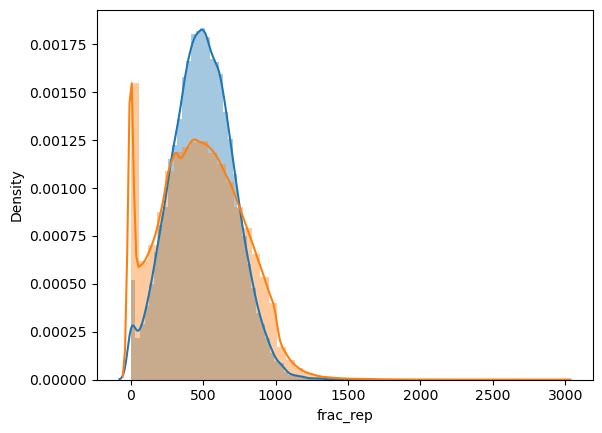

In [85]:

sns.distplot(peaks["frac_rep"]/2)
sns.distplot(frac_rho.frac_rep)

[576.0, 111.0, 963.0, 0.0, 449.0]

In [72]:
scaffold = "NEVH01017591.1"
start_bin = 7000.0	
stop_bin = 9000.0

In [80]:
frac_rho.loc[frac_rho.Scaffold==scaffold].loc[frac_rho.Start_bp>=start_bin].loc[frac_rho.End_bp<=stop_bin].frac_rep.sum()

0.0

In [58]:
frac_df.loc[frac_df.scaffold=="NEVH01017591.1"].head(20)

,scaffold,start_bin,stop_win,frac_rep
619456,NEVH01017591.1,0.0,1000.0,990.0
619457,NEVH01017591.1,1000.0,2000.0,1132.0
619458,NEVH01017591.1,3000.0,4000.0,808.0
619459,NEVH01017591.1,4000.0,5000.0,902.0
619460,NEVH01017591.1,5000.0,6000.0,661.0
619461,NEVH01017591.1,6000.0,7000.0,910.0
619462,NEVH01017591.1,9000.0,10000.0,864.0
619463,NEVH01017591.1,11000.0,12000.0,831.0
619464,NEVH01017591.1,12000.0,13000.0,1052.0
619465,NEVH01017591.1,13000.0,14000.0,939.0
